In [1]:
import glob

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import seaborn as sns

In [2]:
control_files = sorted(glob.glob('tp_ecmwf_control-forecast_2025-01-??_AUS.grib'))

In [3]:
control_files

['tp_ecmwf_control-forecast_2025-01-01_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-02_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-03_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-04_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-05_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-06_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-07_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-08_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-09_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-10_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-11_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-12_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-13_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-14_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-15_AUS.grib',
 'tp_ecmwf_control-forecast_2025-01-16_AUS.grib']

In [4]:
ds_control = xr.open_mfdataset(control_files[:-1], engine='cfgrib')

In [5]:
ds_control

<xarray.Dataset> Size: 720MB
Dimensions:     (time: 30, step: 61, latitude: 277, longitude: 355)
Coordinates:
  * time        (time) datetime64[ns] 240B 2025-01-01 ... 2025-01-15T12:00:00
  * step        (step) timedelta64[ns] 488B 0 days 00:00:00 ... 15 days 00:00:00
  * latitude    (latitude) float64 2kB -10.0 -10.12 -10.25 ... -44.38 -44.5
  * longitude   (longitude) float64 3kB 112.0 112.1 112.2 ... 156.0 156.1 156.2
    number      int64 8B 0
    surface     float64 8B 0.0
    valid_time  (time, step) datetime64[ns] 15kB dask.array<chunksize=(2, 61), meta=np.ndarray>
Data variables:
    tp          (time, step, latitude, longitude) float32 720MB dask.array<chunksize=(2, 61, 277, 355), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-05T10:27 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
ds_perturbed = xr.open_dataset('tp_ecmwf_perturbed-forecast_2025-01-01_AUS.grib', engine='cfgrib')

In [7]:
ds_perturbed

<xarray.Dataset> Size: 2GB
Dimensions:     (number: 50, time: 2, step: 61, latitude: 277, longitude: 355)
Coordinates:
  * number      (number) int64 400B 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * time        (time) datetime64[ns] 16B 2025-01-01 2025-01-01T12:00:00
  * step        (step) timedelta64[ns] 488B 0 days 00:00:00 ... 15 days 00:00:00
  * latitude    (latitude) float64 2kB -10.0 -10.12 -10.25 ... -44.38 -44.5
  * longitude   (longitude) float64 3kB 112.0 112.1 112.2 ... 156.0 156.1 156.2
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 976B ...
Data variables:
    tp          (number, time, step, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-05T10:27 GRIB to CDM+CF via cfgrib-0.9.1...

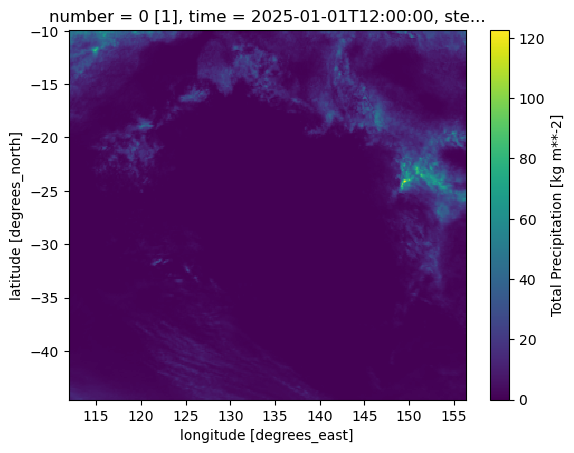

In [8]:
ds_control.isel({'time': 1, 'step': 10})['tp'].plot()

In [9]:
ds_agcd = xr.open_dataset('agcd_v1_precip_total_r005_daily_2025.nc')

In [10]:
ds_agcd

<xarray.Dataset> Size: 894MB
Dimensions:    (lat: 691, nv: 2, lon: 886, time: 365)
Coordinates:
  * lat        (lat) float32 3kB -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon        (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
  * time       (time) datetime64[ns] 3kB 2025-01-01T09:00:00 ... 2025-12-31T0...
Dimensions without coordinates: nv
Data variables:
    lat_bnds   (lat, nv) float32 6kB ...
    lon_bnds   (lon, nv) float32 7kB ...
    time_bnds  (time, nv) datetime64[ns] 6kB ...
    precip     (time, lat, lon) float32 894MB ...
    crs        int32 4B ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       2024-12-31T09:00:00
    date_created:              2025-06-29T22:18:29.536262
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2026-05-08 00:30:37
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2026, ...
    history:

In [11]:
ds_control_hobart = ds_control.sel({'latitude': -42.88, 'longitude': 147.32}, method='nearest')

In [12]:
ds_perturbed_hobart = ds_perturbed.sel({'latitude': -42.88, 'longitude': 147.32}, method='nearest')

In [32]:
ds_agcd_hobart = ds_agcd.sel({'lat': -42.88, 'lon': 147.32}, method='nearest')

In [33]:
ds_agcd_hobart = ds_agcd_hobart.isel(time=slice(1, 16))

In [34]:
ds_agcd_hobart

<xarray.Dataset> Size: 448B
Dimensions:    (nv: 2, time: 15)
Coordinates:
  * time       (time) datetime64[ns] 120B 2025-01-02T09:00:00 ... 2025-01-16T...
    lat        float32 4B -42.9
    lon        float32 4B 147.3
Dimensions without coordinates: nv
Data variables:
    lat_bnds   (nv) float32 8B ...
    lon_bnds   (nv) float32 8B ...
    time_bnds  (time, nv) datetime64[ns] 240B ...
    precip     (time) float32 60B ...
    crs        int32 4B ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       2024-12-31T09:00:00
    date_created:              2025-06-29T22:18:29.536262
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2026-05-08 00:30:37
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2026, ...
    history:

The tp variable is the accumulated rainfall since the beginning of the forecast. That means you need to subtract the previous step from each value to get the rainfall just over the past 6 hours.

The first forecast is 6 UTC / 4pm in Hobart, which lines up pretty close to the typical convention of rainfall being the rainfall to 9am (i.e. the last value on a given day is the rainfall up to 10am). I add 21 hours to 6 UTC so that the 4 values fall on the same day for resampling (i.e. the next day, which is the AGCD convention).

In [35]:
def extract_reality(da_control):
    """Extract reality"""

    da_control_stacked_start = da_control.isel(step=slice(0, 2)).stack({'date': ['time', 'step']})
    da_control_stacked_step = da_control.isel(step=slice(1, 3)).stack({'date': ['time', 'step']})
    times = (da_control_stacked_step.step + da_control_stacked_step.time).values + np.timedelta64(21, 'h')
    values = da_control_stacked_step.values - da_control_stacked_start.values
    df = pd.DataFrame(values, index=times, columns=['tp'])
    df = df.clip(lower=0)
    df = df.resample('D').sum()

    return df
    

def extract_forecast(da):
    """Extract a single forecast."""

    times = (da.step + da.time).values[1:] + np.timedelta64(21, 'h')
    values = da.values[1:] - da.values[0:-1]
    df = pd.DataFrame(values, index=times, columns=['tp'])
    df = df.clip(lower=0)
    df = df.resample('D').sum()
    
    return df


def extract_agcd(da):
    """Extract AGCD data."""

    times = da.time.values
    values = da.values
    df = pd.DataFrame(values, index=times, columns=['precip'])
    df = df.resample('D').mean()

    return df

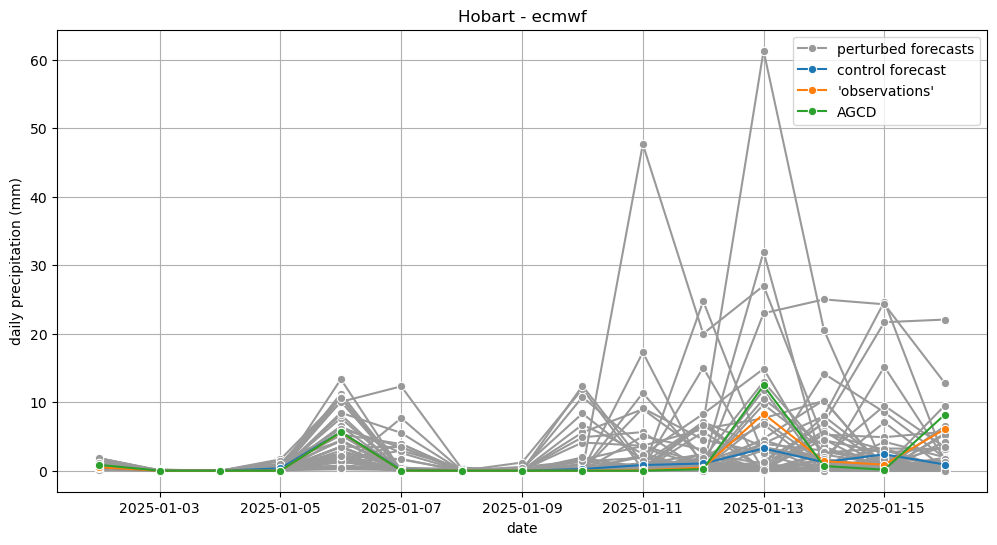

In [36]:
plt.figure(figsize=(12, 6))

n_members = len(ds_perturbed_hobart.number)
for member in range(n_members):
    df_perturbed = extract_forecast(ds_perturbed_hobart['tp'].isel(time=0, number=member))
    label = 'perturbed forecasts' if member == 1 else None
    sns.lineplot(data=df_perturbed, x=df_perturbed.index, y='tp', marker='o', color='0.6', label=label)
#    sns.stripplot(data=df_perturbed, x=df_perturbed.index, y='tp', jitter=True)

df_control = extract_forecast(ds_control_hobart['tp'].isel(time=0))
sns.lineplot(data=df_control, x=df_control.index, y='tp', marker='o', label='control forecast')

df_reality = extract_reality(ds_control_hobart['tp'])
sns.lineplot(data=df_reality, x=df_reality.index, y='tp', marker='o', label="""'observations'""")

df_agcd = extract_agcd(ds_agcd_hobart['precip'])
sns.lineplot(data=df_agcd, x=df_agcd.index, y='precip', marker='o', label='AGCD')

plt.title('Hobart - ecmwf')
plt.xlabel('date')
plt.ylabel('daily precipitation (mm)')
plt.grid()
plt.show()

Daily precipitation is the accumulated 24 hour rainfall up to 9am (AGCD) or 10am (ECMWF) of the listed date.